# Simple MTM1 / Snx17 ODE simulation

This notebook runs **one simulation condition directly from the YAML file**. The other notebooks carry out more specialised runs.

Workflow:
1. Load the YAML and construct the 15-state ODE model.
2. Run and plot the configured equilibration.
3. Start the assay from the completed equilibrated state and add the proteins listed under `assay` in the YAML.
4. Plot normalised PI(3)P depletion and normalised PI(3)P-probe signal loss, with the matching experimental trace overlaid using the experimental csv
5. Plot total membrane-bound MTM1 (`MbA + SMb`).
6. Save the two assay trajectories to separate CSV files at **1-second intervals**.

Keep this notebook, `ode_parameters.yaml`, and the experimental CSV named in the YAML in the same folder. After changing the YAML, **Restart Kernel and Run All**.

## 1. Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from scipy.integrate import solve_ivp

# S = Snx17
# M = MTM1
# P = PI(3)P probe
# A = PI(3)P
# B = PI
# C = Cargo

## 2. Load YAML parameters

In [2]:
CONFIG_PATH = Path("ode_parameters.yaml").resolve()
with CONFIG_PATH.open(encoding="utf-8") as f:
    config = yaml.safe_load(f)

affinities = config["affinities"]
Volume = config["geometry"]["Volume"]
TotalMembraneSA = config["geometry"]["TotalMembraneSA"]

keff_M = config["catalysis"]["keff_M"]
keff_SM = config["catalysis"]["keff_SM"]
if keff_SM is None:
    keff_SM = keff_M

params = dict(config["association_rates"])
ref = config["dissociation_reference"]
for suffix, kd_name in [("SA", "Kd_SA"), ("MA", "Kd_MA"),
                        ("PA", "Kd_PA"), ("PB", "Kd_PB")]:
    reference_koff = ref["probe_A_koff"] if suffix == "PA" else ref["bulk_koff"]
    params["koff_" + suffix] = reference_koff * (affinities[kd_name] / ref["bulk_Kd"])

for suffix, kd_name in [("SM", "Kd_SM"), ("SC", "Kd_SC")]:
    params["koff_" + suffix] = ref["surface_koff"] * (affinities[kd_name] / ref["surface_Kd"])

divisors = config["complex_off_rate_divisors"]
params["koff_SAM"] = params["koff_SA"] / divisors["SAM"]
params["koff_SAC"] = params["koff_SA"] / divisors["SAC"]
params.update(
    keff_M=keff_M,
    keff_SM=keff_SM,
    ka=config["transport"]["ka"],
)

eq_Snx17_conc = config["equilibration"]["Snx17_conc"]
eq_MTM1_conc = config["equilibration"]["MTM1_conc"]
eq_Probe_conc = config["equilibration"]["Probe_conc"]
eq_cargo_conc = config["equilibration"]["cargo_fraction"]

initial_Snx17_conc = config["assay"]["Snx17_conc"]
initial_MTM1_conc = config["assay"]["MTM1_conc"]
initial_Probe_conc = config["assay"]["Probe_conc"]

equilibration_time = config["equilibration"]["time_s"]
simulation_time = config["assay"]["time_s"]

PC_concentration = config["membrane"]["PC_concentration"]
membrane_substrate = config["membrane"]["membrane_substrate"]
membrane_product = config["membrane"]["membrane_product"]

solver_options = dict(config["solver"])
file_settings = config["files"]
experimental_csv = CONFIG_PATH.parent / file_settings["experimental_csv"]
results_csv = CONFIG_PATH.parent / file_settings["results_csv"]

if simulation_time[1] <= simulation_time[0]:
    raise ValueError("Assay end time must be greater than assay start time.")

## 3. Initial state and ODE model

In [3]:
label_list = [
    "[undelivered Snx17]", "[undelivered MTM1]", "[undelivered Pi3P Probe]",
    "[solution Snx17]", "[solution MTM1]", "[solution Pi3P Probe]",
    "[Pi3P-bound Snx17]", "[Pi3P-bound MTM1]", "[Pi3P-bound Pi3P Probe]",
    "[Pi-bound Pi3P Probe]", "[Pi3P-bound Snx17-MTM1]",
    "[Pi3P-bound Snx17-Cargo]", "[Pi3P]", "[Pi]", "[Cargo]"
]

colour_list = [
    "grey", "grey", "grey", "cyan", "green", "olive", "blue", "gold",
    "orange", "purple", "fuchsia", "tan", "red", "plum", "thistle"
]

equilibration_concentrations = [
    0,                         # Sa
    0,                         # Ma
    0,                         # Pa
    eq_Snx17_conc,             # Sf
    eq_MTM1_conc,              # Mf
    eq_Probe_conc,             # Pf
    0,                         # SbA
    0,                         # MbA
    0,                         # PbA
    0,                         # PbB
    0,                         # SMb
    0,                         # SbC
    PC_concentration * membrane_substrate,  # A = PI(3)P
    PC_concentration * membrane_product,    # B = PI
    PC_concentration * eq_cargo_conc,       # C = Cargo
]


def change_in_bidning(kon, substrate, koff, free_form, bound_form):
    return kon * substrate * free_form - koff * bound_form


def model(t, y):
    Sa, Ma, Pa, Sf, Mf, Pf, SbA, MbA, PbA, PbB, SMb, SbC, A, B, C = y

    kon_SA   = params["kon_SA"]
    koff_SA  = params["koff_SA"]
    kon_MA   = params["kon_MA"]
    koff_MA  = params["koff_MA"]
    kon_PA   = params["kon_PA"]
    koff_PA  = params["koff_PA"]
    kon_PB   = params["kon_PB"]
    koff_PB  = params["koff_PB"]
    kon_SM   = params["kon_SM"]
    koff_SM  = params["koff_SM"]
    koff_SAM = params["koff_SAM"]
    kon_SC   = params["kon_SC"]
    koff_SC  = params["koff_SC"]
    koff_SAC = params["koff_SAC"]
    keff_M   = params["keff_M"]
    keff_SM  = params["keff_SM"]
    ka       = params["ka"]

    # Free lipid/cargo available for binding
    A_bind = max((A - SbA - MbA - PbA - (SMb * 2) - SbC), 0.0)
    B_bind = max((B - PbB), 0.0)
    C_bind = max((C - SbC), 0.0)

    # Convert nM to molecules/um2 for 2D binding calculations
    aMbA = ((MbA * 0.602) * Volume) / TotalMembraneSA
    aSbA = ((SbA * 0.602) * Volume) / TotalMembraneSA
    aSMb = ((SMb * 0.602) * Volume) / TotalMembraneSA
    aC_bind = ((C_bind * 0.602) * Volume) / TotalMembraneSA
    aSbC = ((SbC * 0.602) * Volume) / TotalMembraneSA

    # 2D reaction rates (molecules/um2/s)
    SMb_rate_mum2 = change_in_bidning(kon_SM, aMbA, koff_SM, aSbA, aSMb)
    SbC_rate_mum2 = change_in_bidning(kon_SC, aC_bind, koff_SC, aSbA, aSbC)

    # Convert 2D rates back to nM/s
    SMb_rate_nM = (SMb_rate_mum2 * TotalMembraneSA) / (0.602 * Volume)
    SbC_rate_nM = (SbC_rate_mum2 * TotalMembraneSA) / (0.602 * Volume)

    # Diffusion from compartment 1 -> compartment 2
    dSa = -(ka * Sa)
    dMa = -(ka * Ma)
    dPa = -(ka * Pa)

    # Free S, M and P
    dSf = -change_in_bidning(kon_SA, A_bind, koff_SA, Sf, SbA) + \
          (koff_SAC * SbC) + (koff_SAM * SMb) + (ka * Sa)

    dMf = -change_in_bidning(kon_MA, A_bind, koff_MA, Mf, MbA) + \
          (koff_SAM * SMb) + (ka * Ma)

    dPf = -change_in_bidning(kon_PA, A_bind, koff_PA, Pf, PbA) + \
          -change_in_bidning(kon_PB, B_bind, koff_PB, Pf, PbB) + (ka * Pa)

    # Binding from compartment 2 -> compartment 3
    dSbA = change_in_bidning(kon_SA, A_bind, koff_SA, Sf, SbA) \
           - SMb_rate_nM - SbC_rate_nM

    dMbA = change_in_bidning(kon_MA, A_bind, koff_MA, Mf, MbA) \
           - SMb_rate_nM

    dPbA = change_in_bidning(kon_PA, A_bind, koff_PA, Pf, PbA)
    dPbB = change_in_bidning(kon_PB, B_bind, koff_PB, Pf, PbB)

    # Snx17-MTM1 and Snx17-cargo complexes
    dSMb = SMb_rate_nM - (koff_SAM * SMb)
    dSbC = SbC_rate_nM - (koff_SAC * SbC)

    # MTM1 catalysis: PI(3)P -> PI
    dB = (keff_M * MbA * A_bind) + (keff_SM * SMb * A_bind)
    dA = -dB

    return [dSa, dMa, dPa, dSf, dMf, dPf, dSbA, dMbA, dPbA, dPbB,
            dSMb, dSbC, dA, dB, 0]


## 4. Equilibration

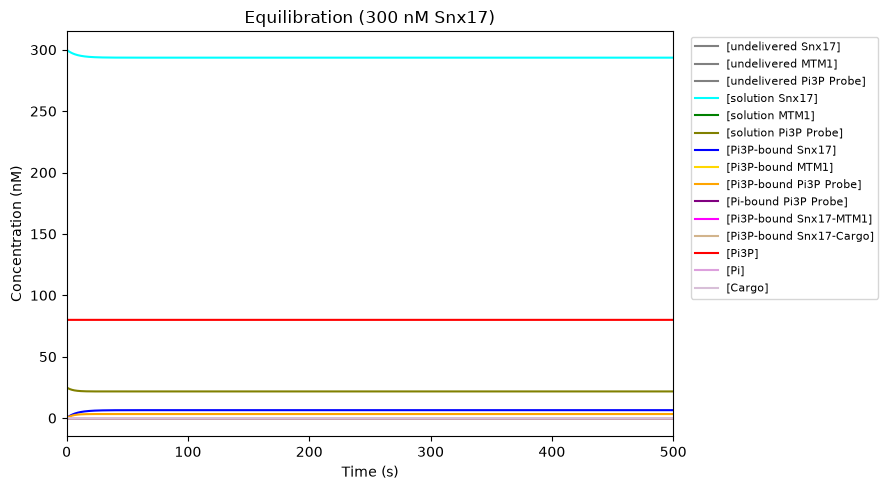

Equilibration complete.


In [4]:
sol_eq = solve_ivp(
    model,
    equilibration_time,
    np.asarray(equilibration_concentrations, dtype=float),
    **solver_options,
)
if not sol_eq.success:
    raise RuntimeError(sol_eq.message)

y_eq = sol_eq.y[:, -1].copy()

fig, ax = plt.subplots(figsize=(9, 5))
for i, name in enumerate(label_list):
    ax.plot(sol_eq.t, sol_eq.y[i], label=name, color=colour_list[i])
ax.set(
    title=f"Equilibration ({eq_Snx17_conc:g} nM Snx17)",
    xlabel="Time (s)",
    ylabel="Concentration (nM)",
    xlim=equilibration_time,
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

print("Equilibration complete.")

## 5. Assay: normalised PI(3)P and probe signal

Experimental overlay: 25nM MTM1 + 300nM Snx17


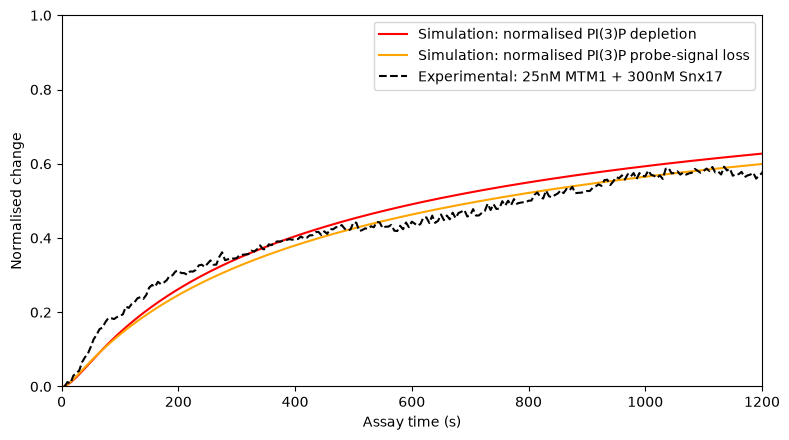

Saved results_normalised_signals.csv (1201 rows; 1-second assay output).


In [7]:
# Preserve the complete equilibrated state, then add the configured assay proteins once.
assay_initial = y_eq.copy()
assay_initial[3] += initial_Snx17_conc
assay_initial[4] += initial_MTM1_conc
assay_initial[5] += initial_Probe_conc

# Return assay values once per second.
assay_start = float(simulation_time[0])
assay_end = float(simulation_time[1])
assay_times = np.arange(np.ceil(assay_start), np.floor(assay_end) + 1.0, 1.0)
if len(assay_times) == 0 or assay_times[0] != assay_start:
    assay_times = np.insert(assay_times, 0, assay_start)
if assay_times[-1] != assay_end:
    assay_times = np.append(assay_times, assay_end)
assay_times = np.unique(assay_times)

sol_assay = solve_ivp(
    model,
    simulation_time,
    assay_initial,
    t_eval=assay_times,
    **solver_options,
)
if not sol_assay.success:
    raise RuntimeError(sol_assay.message)


def normalised_loss(values):
    values = np.asarray(values, dtype=float)
    peak = np.max(values)
    if peak <= 0:
        return np.full_like(values, np.nan)
    return 1.0 - values / peak

normalised_probe_loss = normalised_loss(sol_assay.y[8])
normalised_PI3P_depletion = normalised_loss(sol_assay.y[12])

# Plot simulation trajectories.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sol_assay.t, normalised_PI3P_depletion,
        label="Simulation: normalised PI(3)P depletion", color="red")
ax.plot(sol_assay.t, normalised_probe_loss,
        label="Simulation: normalised PI(3)P probe-signal loss", color="orange")

if experimental_csv.is_file():
    df = pd.read_csv(experimental_csv)
    df_time = df[file_settings["time_column"]] * file_settings["time_to_seconds"]
    experimental_column = file_settings["A_column"]

    if experimental_column in df.columns:
        ax.plot(df_time, df[experimental_column], "--", color="black",
                label=f"Experimental: {experimental_column}")
        print(f"Experimental overlay: {experimental_column}")
    else:
        print("Experimental CSV found, but no matching configured data column was found.")
else:
    print(f"Experimental overlay skipped: {experimental_csv.name} not found.")

ax.set(
    xlabel="Assay time (s)",
    ylabel="Normalised change",
    xlim=simulation_time,
    ylim=(0, 1),
)
ax.legend()
fig.tight_layout()
plt.show()

# CSV for the trajectories shown in this assay plot.
signal_csv = results_csv.with_name(results_csv.stem + "_normalised_signals.csv")
signal_table = pd.DataFrame({
    "time_s": sol_assay.t,
    "normalised_PI3P_depletion": normalised_PI3P_depletion,
    "normalised_PI3P_probe_signal_loss": normalised_probe_loss,
    "total_PI3P_nM": sol_assay.y[12],
    "bound_PI3P_probe_nM": sol_assay.y[8],
})
signal_table.to_csv(signal_csv, index=False)
print(f"Saved {signal_csv.name} ({len(signal_table)} rows; 1-second assay output).")

## 6. Assay: membrane-bound MTM1

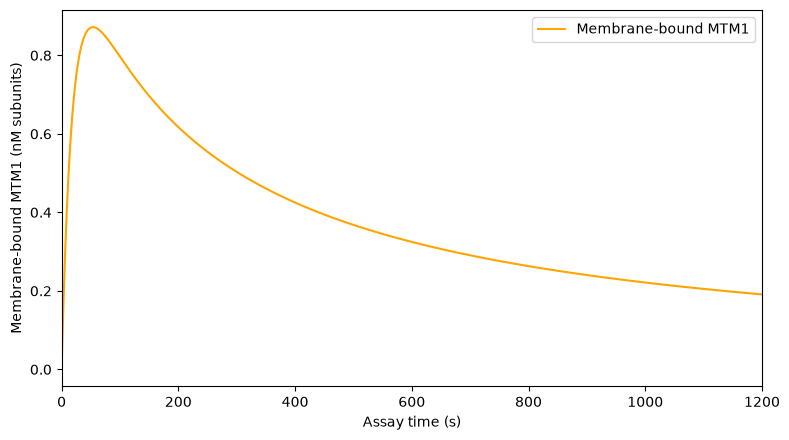

Saved results_membrane_bound_MTM1.csv (1201 rows; 1-second assay output).


In [6]:
membrane_bound_MTM1 = sol_assay.y[7] + sol_assay.y[10]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sol_assay.t, membrane_bound_MTM1, color="orange", label="Membrane-bound MTM1")
ax.set(
    xlabel="Assay time (s)",
    ylabel="Membrane-bound MTM1 (nM subunits)",
    xlim=simulation_time,
)
ax.legend()
fig.tight_layout()
plt.show()

# Separate CSV for the trajectory shown in this plot.
mtm1_csv = results_csv.with_name(results_csv.stem + "_membrane_bound_MTM1.csv")
mtm1_table = pd.DataFrame({
    "time_s": sol_assay.t,
    "membrane_bound_MTM1_nM_subunits": membrane_bound_MTM1,
})
mtm1_table.to_csv(mtm1_csv, index=False)
print(f"Saved {mtm1_csv.name} ({len(mtm1_table)} rows; 1-second assay output).")